In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install itables
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import xgboost as xg
from itables import init_notebook_mode
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

init_notebook_mode(all_interactive=True)

## MLPR
y = ALLSKY_SFC_SW_DWN <br>
x = other features

In [3]:
df = pd.read_csv('/content/drive/MyDrive/colab/mlpr/solar_dataset.csv')

: 

: 

: 

In [4]:
display(df["City"].unique())

array(['Amaravati', 'Visakhapatnam', 'Guwahati', 'Patna', 'Chandigarh',
       'Delhi', 'Ahmedabad', 'Gurugram', 'Jorapokhar', 'Bengaluru',
       'Thiruvananthapuram', 'Mumbai', 'Shillong', 'Bhopal',
       'Brajrajnagar', 'Talcher', 'Amritsar', 'Jaipur', 'Hyderabad',
       'Chennai', 'Coimbatore', 'Lucknow', 'Kolkata'], dtype=object)

In [5]:
display(df.columns)

Index(['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
       'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket',
       'City', 'State', 'StationName', 'Latitude', 'Longitude', 'Datetime_ISO',
       'Date', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DNI', 'ALLSKY_SFC_SW_DIFF',
       'ALLSKY_KT', 'T2M', 'RH2M', 'WS10M', 'WD10M', 'PS', 'PRECTOTCORR',
       'CLOUD_AMT', 'CLRSKY_SFC_SW_DWN', 'AOD_55', 'ATM_ATTENUATION',
       'solar_zenith', 'solar_elevation', 'solar_azimuth'],
      dtype='object')

In [6]:
# split the Datetime column into date and time
df['Date'] = df['Datetime'].str.split(' ').str[0]
df['Time'] = df['Datetime'].str.split(' ').str[1]

df.drop(columns=['Datetime'], inplace=True)
df.drop(columns=['Datetime_ISO'], inplace=True)

In [7]:
len(df["StationId"].unique())

102

In [8]:
df = df[df['solar_elevation'] > 10].copy()

In [9]:
print(df.isna().sum())

StationId                  0
PM2.5                 167486
PM10                  290338
NO                    150153
NO2                   140123
NOx                   130612
NH3                   338926
CO                    116412
SO2                   208227
O3                    192491
Benzene               224249
Toluene               285184
Xylene                596527
AQI                   142400
AQI_Bucket            142400
City                       0
State                      0
StationName                0
Latitude                   0
Longitude                  0
Date                       0
ALLSKY_SFC_SW_DWN          0
ALLSKY_SFC_SW_DNI          0
ALLSKY_SFC_SW_DIFF         0
ALLSKY_KT                  0
T2M                        0
RH2M                       0
WS10M                      0
WD10M                      0
PS                         0
PRECTOTCORR                0
CLOUD_AMT                  0
CLRSKY_SFC_SW_DWN          0
AOD_55                     0
ATM_ATTENUATIO

In [10]:
display(df.describe())

Loading ITables v2.7.0 from the internet... (need help?)


In [11]:
# Step 1: Impute Missing Values

# Ensure Date and Time are handled correctly for sorting
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['StationId', 'Date', 'Time'])

# 1. Linear Interpolation (Station-wise)
pollutant_cols = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 
    'O3', 'Benzene', 'Toluene', 'Xylene'
]

print("Starting Station-wise interpolation...")
# We limit to 2 consecutive hours to avoid fabricating large blocks of data
for col in pollutant_cols:
    df[col] = df.groupby('StationId')[col].transform(
        lambda x: x.interpolate(method='linear', limit=2)
    )

# 2. City-Hour Median Imputation
print("Filling remaining gaps with City-Hour medians...")
for col in pollutant_cols:
    df[col] = df[col].fillna(df.groupby(['City', 'Time'])[col].transform('median'))

# 3. Handle AQI and AQI_Bucket
df['AQI'] = df['AQI'].fillna(df.groupby(['City', 'Time'])['AQI'].transform('median'))

# For the categorical AQI_Bucket, we use the most frequent (mode) for that city
df['AQI_Bucket'] = df.groupby('City')['AQI_Bucket'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown")
)

# 4. Final Cleanup
# If any Xylene or NH3 values remain NaN (because entire cities lack data), 
# fill with a global median to avoid dropping too many rows.
df[pollutant_cols] = df[pollutant_cols].fillna(df[pollutant_cols].median())

# Confirm no missing values remain in essential solar columns [cite: 132, 188]
essential_cols = ['ALLSKY_SFC_SW_DWN', 'solar_zenith', 'AOD_55']
df = df.dropna(subset=essential_cols)

print("Step 1 Complete. Missing values:")
print(df[pollutant_cols].isnull().sum())

Starting Station-wise interpolation...
Filling remaining gaps with City-Hour medians...
Step 1 Complete. Missing values:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
dtype: int64


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Select only the "Gas" pollutants (excluding PM2.5 and PM10 which are primary reflectors)
gas_features = ['NO', 'NO2', 'NOx', 'CO', 'NH3', 'Benzene', 'Toluene', 'Xylene']

# 2. Standardize these features (Mean=0, Std=1)Index(['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',

scaler = StandardScaler()
gas_scaled = scaler.fit_transform(df[gas_features])

# 3. Apply PCA
# We target 1 component to create a single "Gas Emission Index"
pca = PCA(n_components=1)
df['Gas_Pollution_Index'] = pca.fit_transform(gas_scaled)

# 4. Check how much information we kept
explained_variance = pca.explained_variance_ratio_[0]
print(f"The 'Gas_Pollution_Index' captures {explained_variance:.2%} of the variance from the 8 raw gases.")

# 5. Drop the raw gas columns to reduce dimensionality
df_reduced = df.drop(columns=gas_features)

The 'Gas_Pollution_Index' captures 32.68% of the variance from the 8 raw gases.


In [13]:
# Step 2: Create Temporal Features

df['Date'] = pd.to_datetime(df['Date'])

# 1. Extract numerical components from 'Time' and 'Date'
df['Hour'] = pd.to_timedelta(df['Time'].astype(str)).dt.components['hours']
df['DayOfYear'] = df['Date'].dt.dayofyear

# 2. Cyclical Encoding for Hours (24-hour cycle)
df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# 3. Cyclical Encoding for Day of Year (365.25-day cycle)
# This helps the model learn the seasonal solar path in India
df['day_sin'] = np.sin(2 * np.pi * df['DayOfYear'] / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df['DayOfYear'] / 365.25)

# 4. Create a "Month" feature for easy grouping/analysis later
df['Month'] = df['Date'].dt.month

# Drop the intermediate linear columns if you want to keep the dataset lean
df = df.drop(columns=['Hour', 'DayOfYear'])

print("Temporal features created: hour_sin, hour_cos, day_sin, day_cos")

Temporal features created: hour_sin, hour_cos, day_sin, day_cos


In [ ]:
# Step 3: Create Physical Interaction Features

# High humidity causes particles to swell, increasing light scattering
df['Aerosol_Humidity_Interaction'] = df['PM2.5'] * df['RH2M']

# 2. Atmospheric Path Length (Air Mass)
# Sunlight travels through more atmosphere when the sun is low.
# Air Mass is approximately 1 / cos(zenith). 
# We convert zenith to radians for the calculation.
df['zenith_rad'] = np.radians(df['solar_zenith'])
df['Air_Mass'] = 1 / np.cos(df['zenith_rad'])

# 3. Pollution-Path Interaction
# Pollution has a disproportionately stronger effect at high zenith angles
df['Pollution_Path_Impact'] = df['PM2.5'] * df['Air_Mass']

# 4. Clearness Index Normalization
# Helps the model understand how much radiation is lost compared to a clear sky
# While ALLSKY_KT is in your data, creating a custom ratio against 
# your specific CLRSKY_SFC_SW_DWN can provide a cleaner signal.
df['Clear_Sky_Ratio'] = df['ALLSKY_SFC_SW_DWN'] / (df['CLRSKY_SFC_SW_DWN'] + 1e-5)

# 5. Wind-Pollution Dispersion
# High wind speed helps clear out aerosol buildup.
df['Wind_Dispersion_Index'] = df['WS10M'] / (df['PM2.5'] + 1e-5)

print("Physical Interaction features created successfully.")

Physical Interaction features created successfully.


In [15]:
# Step 4: Encode Categorical Spatial Features

# 1. Target Encoding for Cities and Stations
# This helps the model understand that some cities are naturally sunnier than others.
city_means = df.groupby('City')['ALLSKY_SFC_SW_DWN'].mean()
df['City_Encoded'] = df['City'].map(city_means)

station_means = df.groupby('StationId')['ALLSKY_SFC_SW_DWN'].mean()
df['Station_Encoded'] = df['StationId'].map(station_means)

# 2. Ordinal Encoding for AQI Bucket
# AQI Buckets have a natural order (Good < Satisfactory < ... < Severe)
aqi_order = {
    'Good': 1, 
    'Satisfactory': 2, 
    'Moderate': 3, 
    'Poor': 4, 
    'Very Poor': 5, 
    'Severe': 6
}
df['AQI_Bucket_Numeric'] = df['AQI_Bucket'].map(aqi_order).fillna(0)

# 3. State-level Grouping (Optional)
# Adds regional context (e.g., North India vs South India)
state_means = df.groupby('State')['ALLSKY_SFC_SW_DWN'].mean()
df['State_Encoded'] = df['State'].map(state_means)

print("Categorical spatial features encoded.")

Categorical spatial features encoded.


In [23]:
# Step 5: Prepare Final Dataset for Modeling

# 1. Log Transform skewed pollution features
skewed_features = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'AOD_55']
for col in skewed_features:
    df[col] = np.log1p(df[col])

# 2. Define your final feature list (X) and Target (y)
# We exclude the original text and the raw timestamps
features = [
    'solar_zenith', 'solar_elevation', 'solar_azimuth', 'Air_Mass',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'PM2.5', 'PM10', 'Gas_Pollution_Index', 'AOD_55', 
    'Aerosol_Humidity_Interaction', 'T2M', 'RH2M', 'WS10M', 'CLOUD_AMT',
    'City_Encoded', 'Station_Encoded', 'AQI_Bucket_Numeric'
]
# 'NO2', 'SO2', 'CO',
X = df[features]
y = df['ALLSKY_SFC_SW_DWN']

# 3. Chronological Split (No Shuffling!)
# Since you have 3 years, let's take the first 80% for training
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training set size: {len(X_train)} hours")
print(f"Testing set size: {len(X_test)} hours")

Training set size: 596396 hours
Testing set size: 149099 hours


In [24]:
model = xg.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    n_jobs=-1 
)

print("Training the model on 23 cities' data...")
model.fit(X_train, y_train, 
          eval_set=[(X_test, y_test)], 
          verbose=False)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.2f} W/m^2")
print(f"MAE: {mae:.2f} W/m^2")

# Assuming 'model' is your trained XGBoost regressor
importance_scores = model.get_booster().get_score(importance_type='gain')

# Convert to a sorted DataFrame
import pandas as pd
feat_importance = pd.DataFrame({
    'Feature': list(importance_scores.keys()),
    'Importance': list(importance_scores.values())
}).sort_values(by='Importance', ascending=False)

print(feat_importance)

Training the model on 23 cities' data...
Model Performance:
R-squared: 0.9362
RMSE: 65.53 W/m^2
MAE: 45.00 W/m^2
                         Feature    Importance
5                       hour_cos  1.066249e+08
4                       hour_sin  2.143161e+07
3                       Air_Mass  7.994430e+06
16                     CLOUD_AMT  3.084298e+06
1                solar_elevation  3.003650e+06
2                  solar_azimuth  2.748552e+06
0                   solar_zenith  2.736346e+06
13                           T2M  1.323639e+06
11                        AOD_55  1.239825e+06
18               Station_Encoded  6.146096e+05
6                        day_sin  5.707487e+05
14                          RH2M  5.322126e+05
17                  City_Encoded  5.286946e+05
7                        day_cos  3.651503e+05
19            AQI_Bucket_Numeric  2.072937e+05
15                         WS10M  1.888130e+05
12  Aerosol_Humidity_Interaction  1.864741e+05
9                           PM10  1.03087

In [ ]:
# # 1. Extract importance scores from the trained model
# importance = model.get_booster().get_score(importance_type='gain')

# # 2. Convert to a DataFrame for easy plotting
# importance_df = pd.DataFrame({
#     'Feature': list(importance.keys()),
#     'Importance': list(importance.values())
# }).sort_values(by='Importance', ascending=True)

# # 3. Plot the results
# plt.figure(figsize=(10, 8))
# plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
# plt.xlabel('Importance Score (Gain)')
# plt.title('Feature Importance: What Drives Solar Illuminance in 23 Cities?')
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.show()

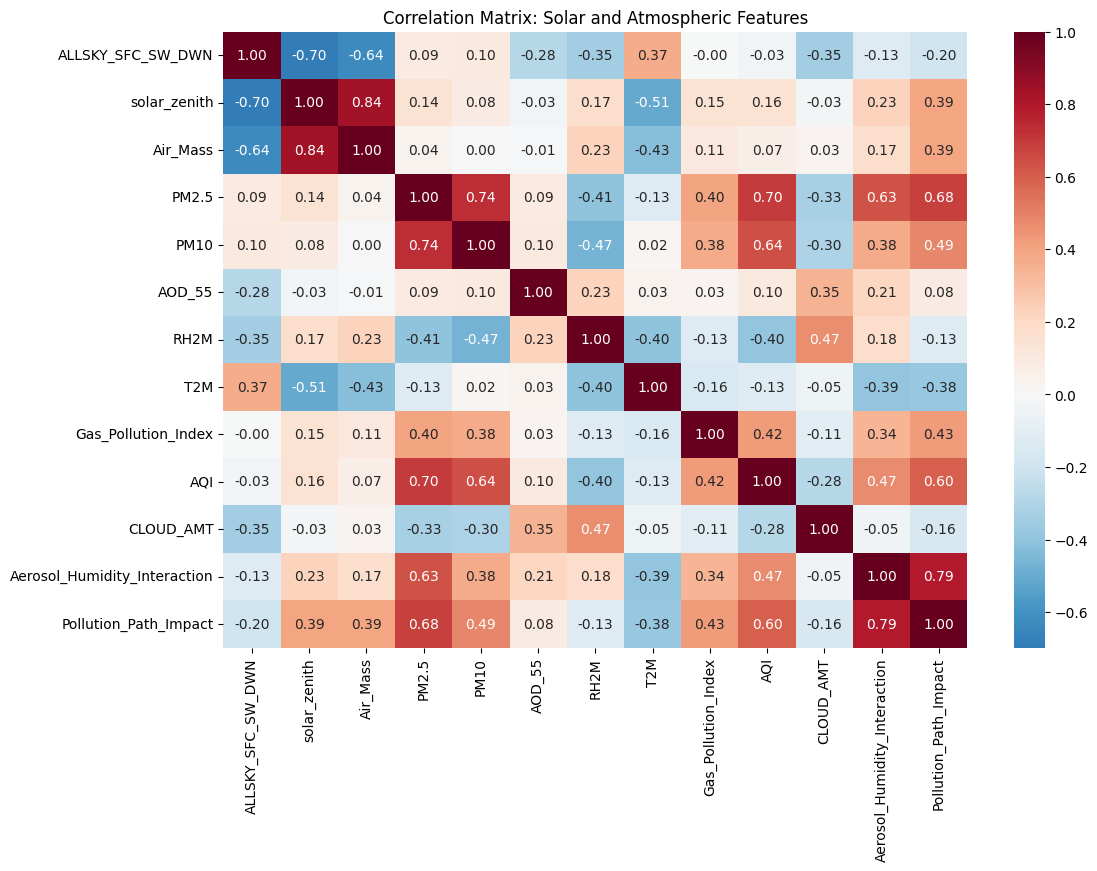

In [19]:

# 1. Select the most relevant features for the matrix
# Including the target (y) and core independent variables (X)
# corr_features = [
#     'ALLSKY_SFC_SW_DWN', 'solar_zenith', 'Air_Mass', 
#     'PM2.5', 'PM10', 'AOD_55', 'RH2M', 'T2M', 'NO2', 'SO2', 'CO', 'NH3', 'Benzene', 'Toluene', 
#     'Xylene', 'AQI',
#     'CLOUD_AMT', 'Aerosol_Humidity_Interaction', 'Pollution_Path_Impact',
# ]

corr_features = [
    'ALLSKY_SFC_SW_DWN', 'solar_zenith', 'Air_Mass', 
    'PM2.5', 'PM10', 'AOD_55', 'RH2M', 'T2M', 'Gas_Pollution_Index', 'AQI',
    'CLOUD_AMT', 'Aerosol_Humidity_Interaction', 'Pollution_Path_Impact',
]

# 2. Calculate the correlation
corr_matrix = df[corr_features].corr()

# 3. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Matrix: Solar and Atmospheric Features')
plt.show()

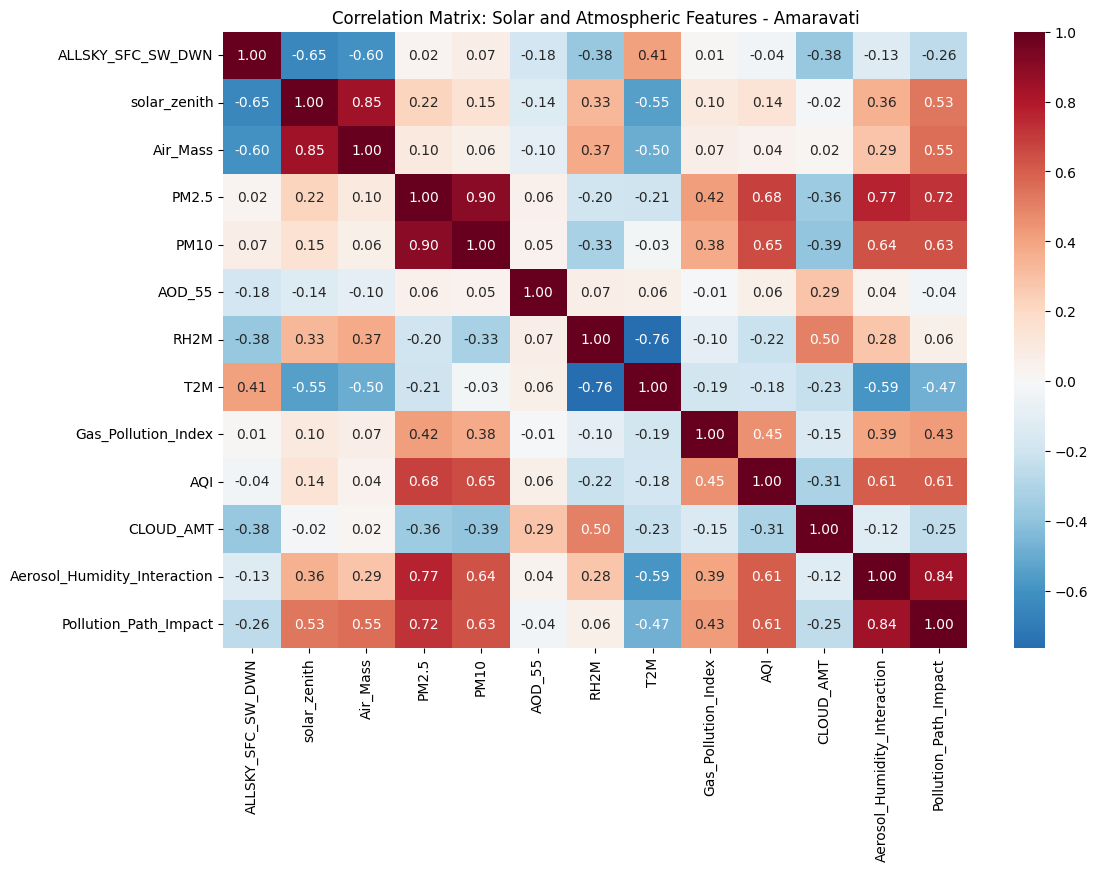

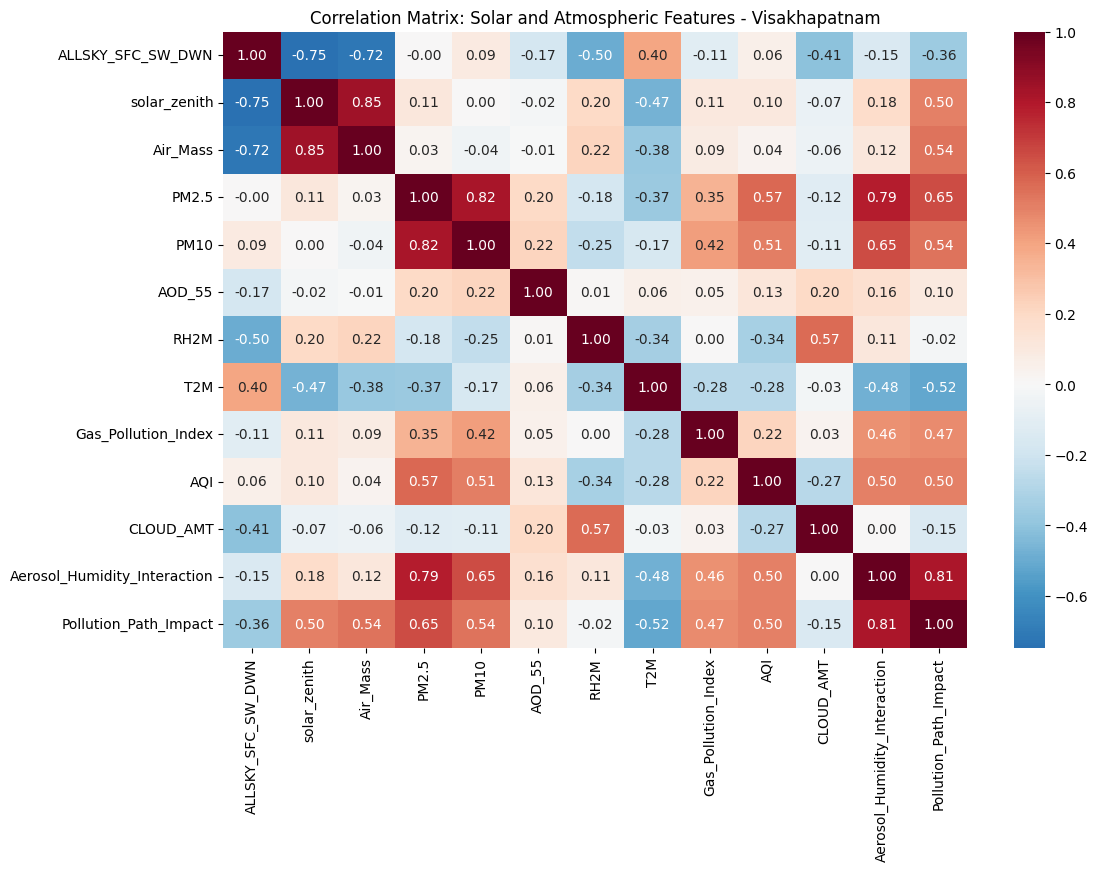

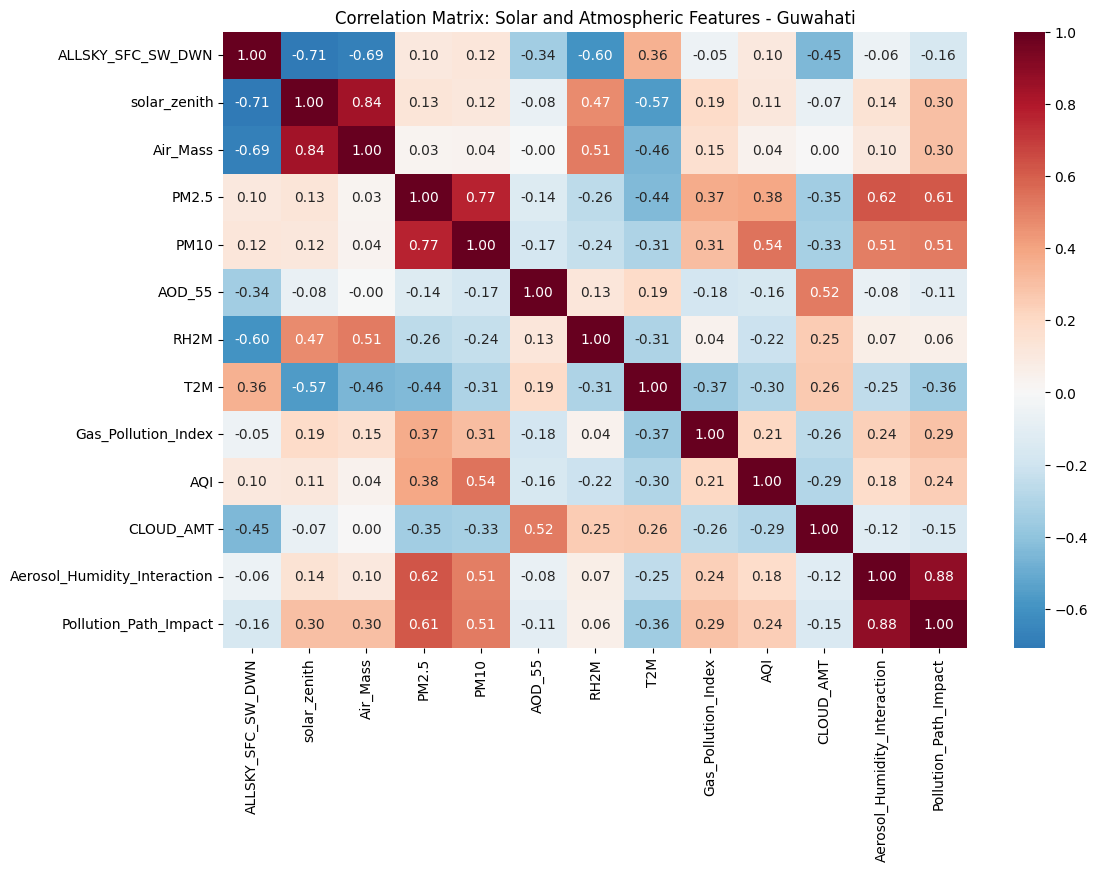

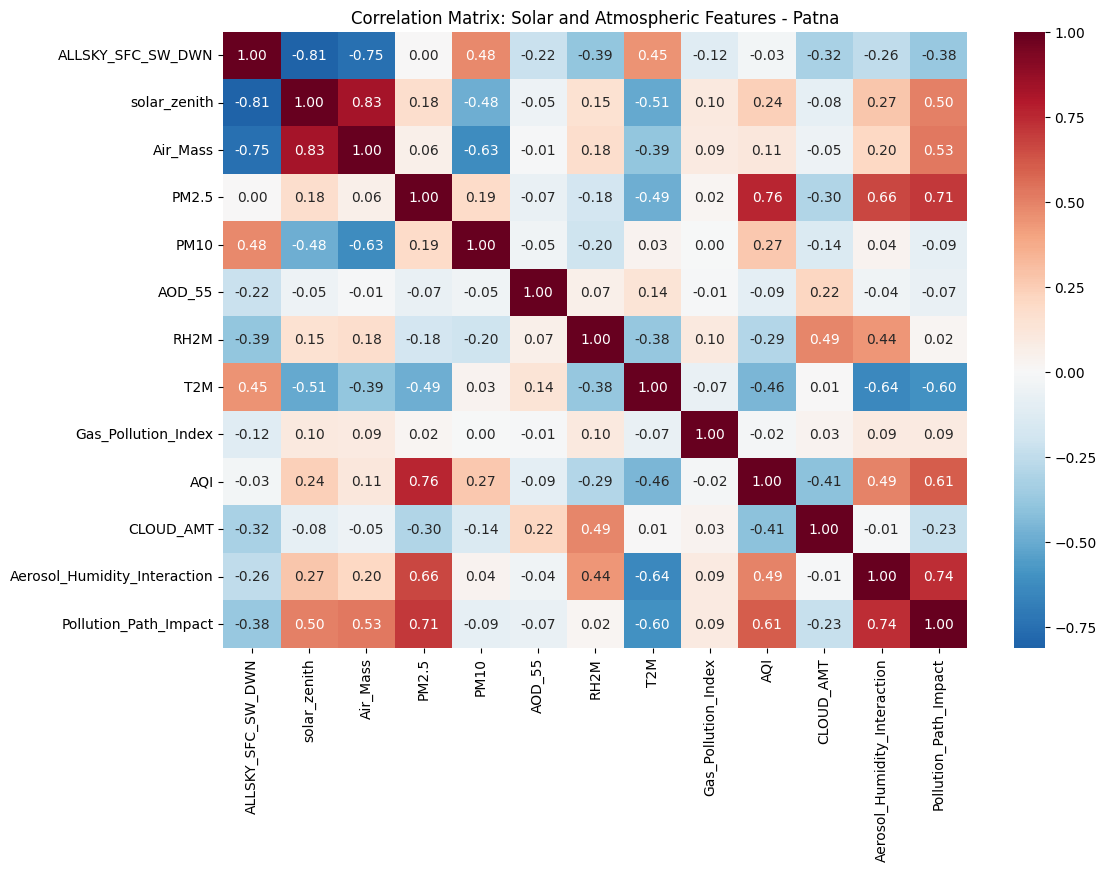

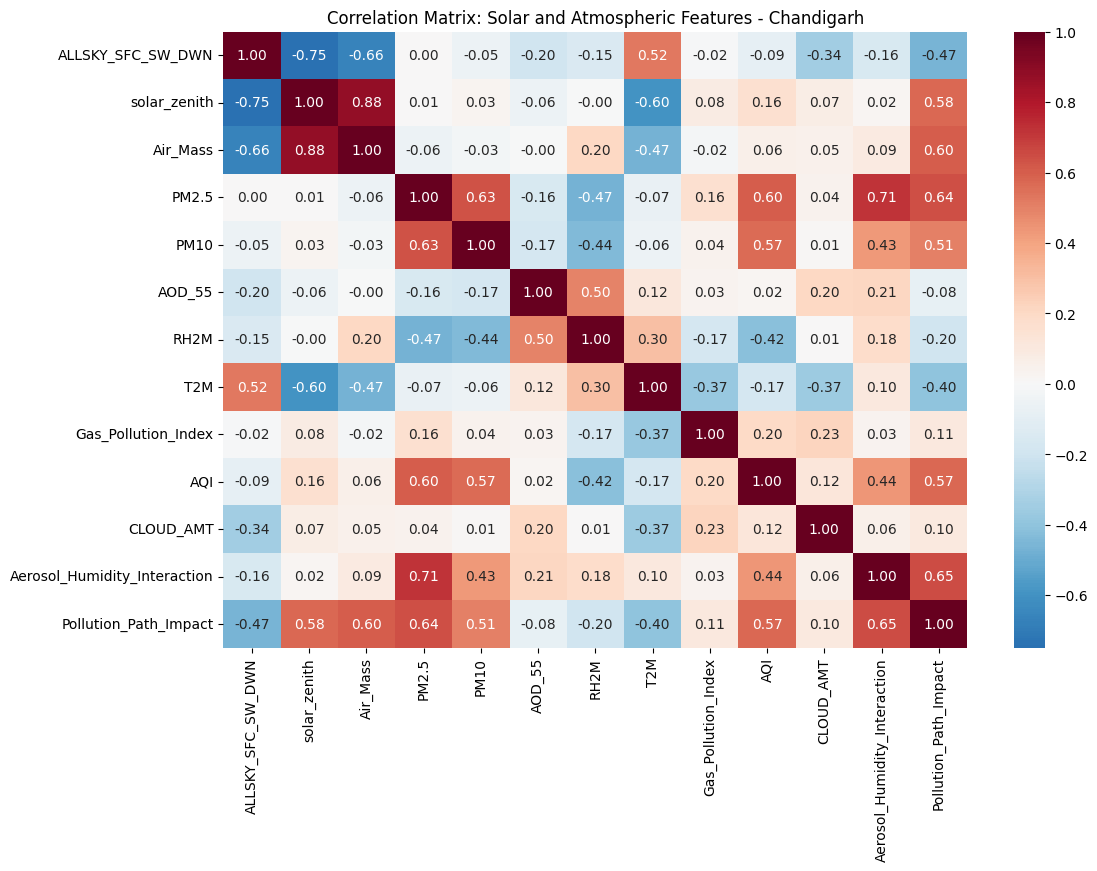

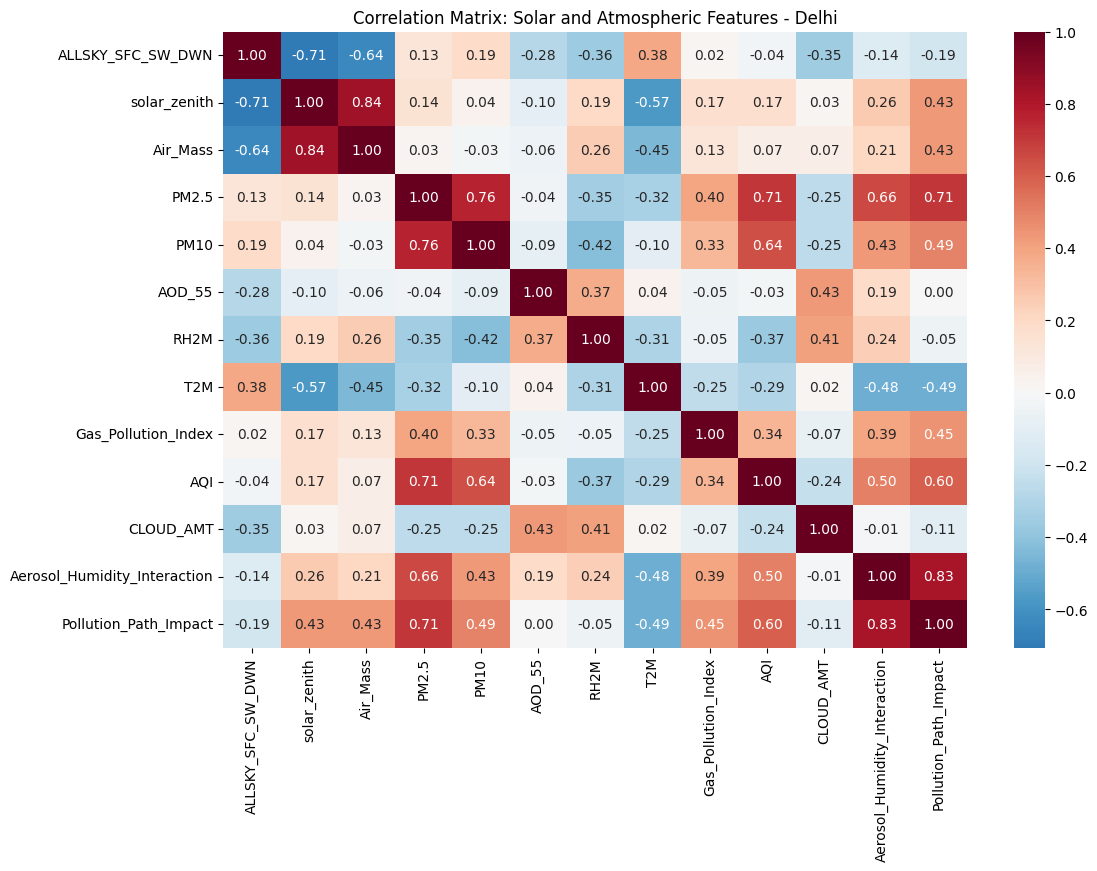

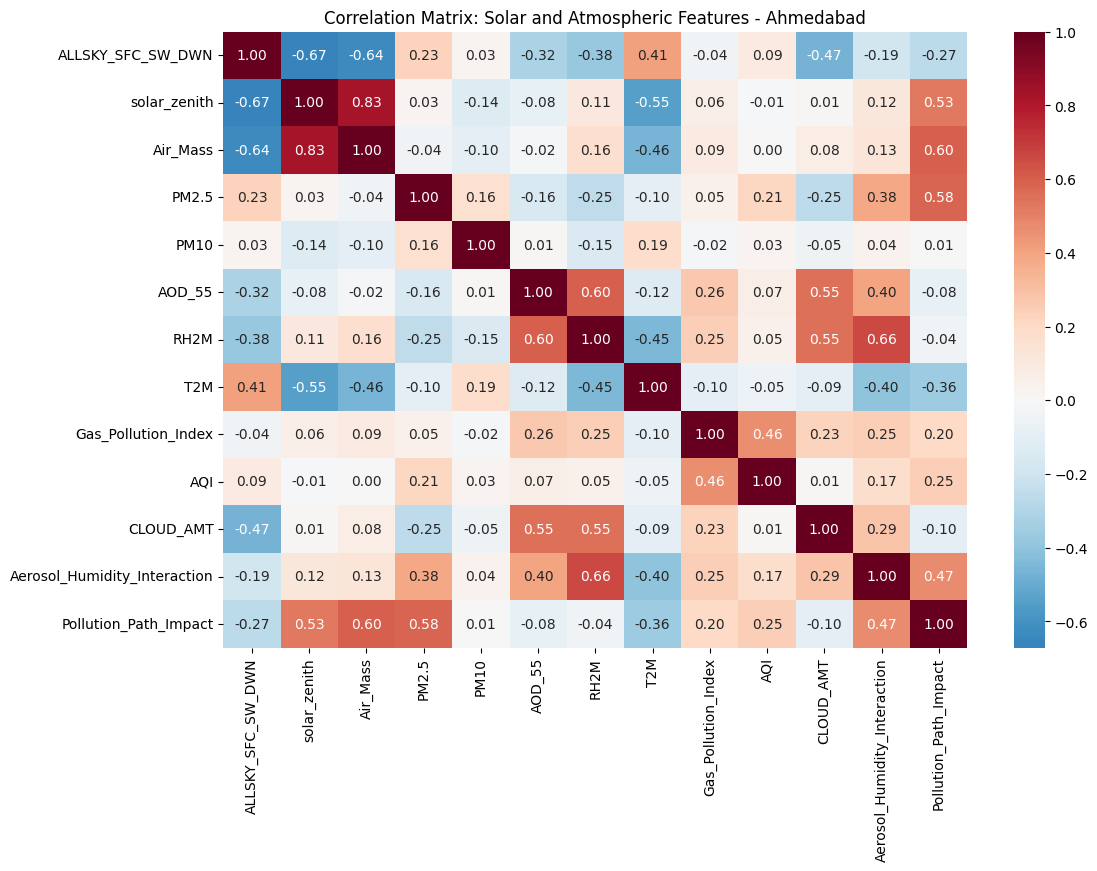

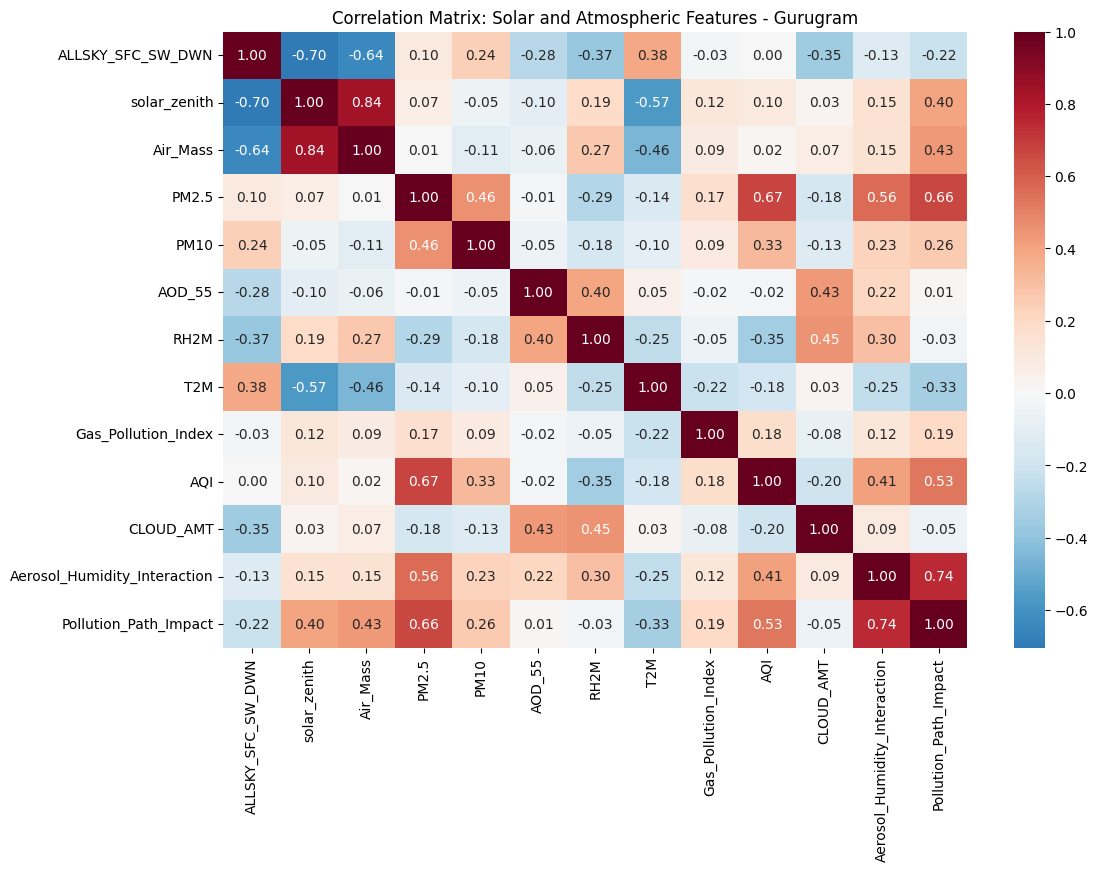

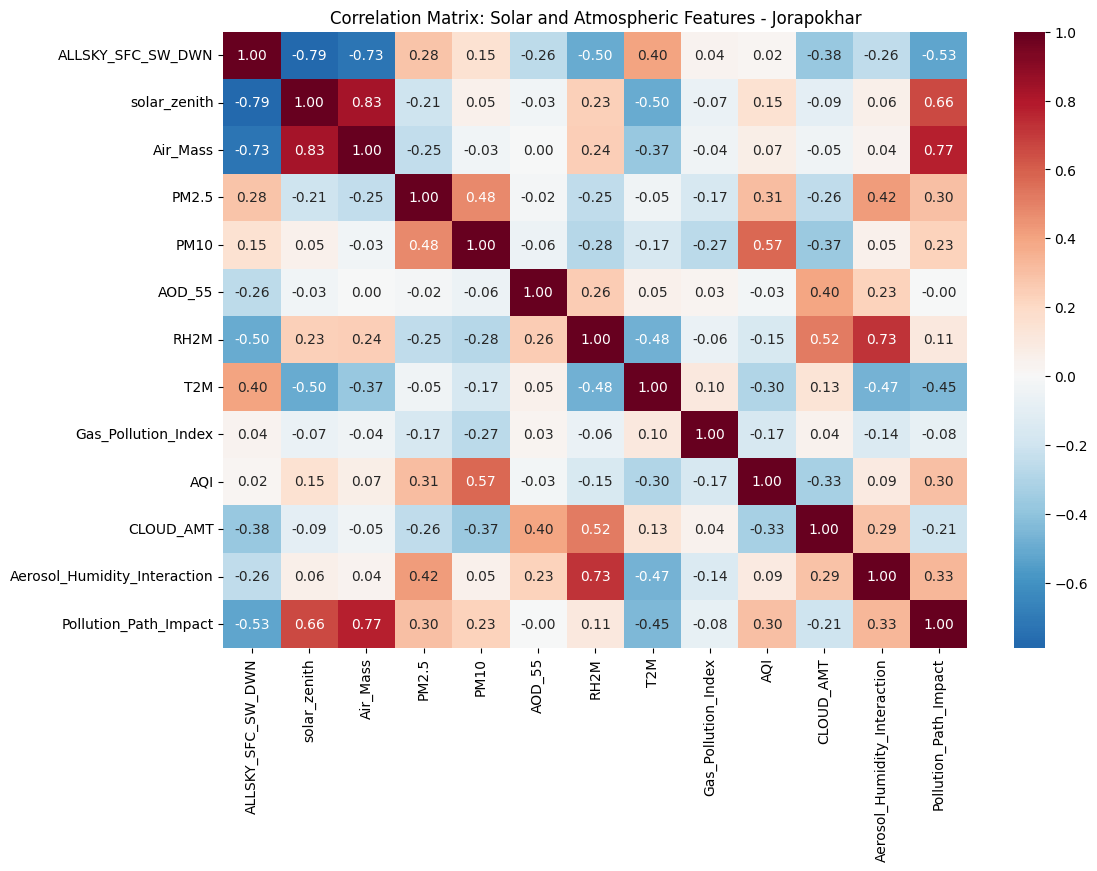

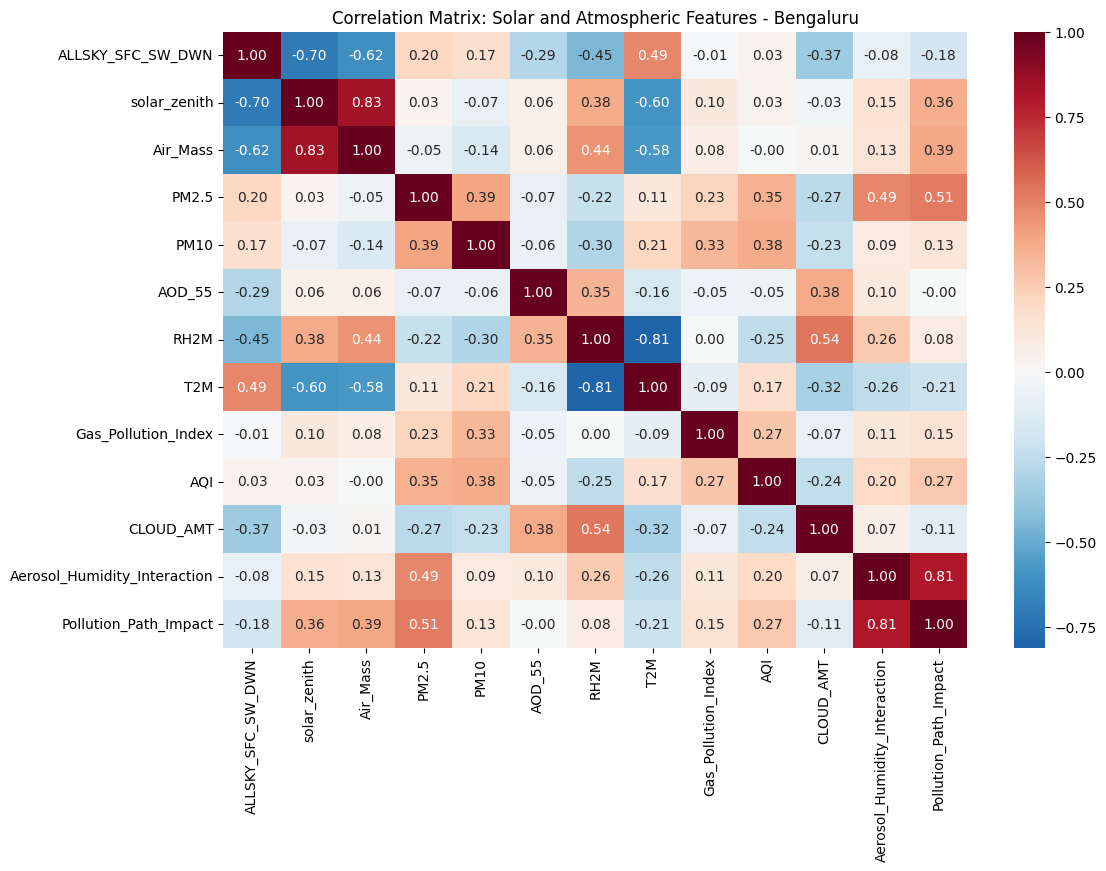

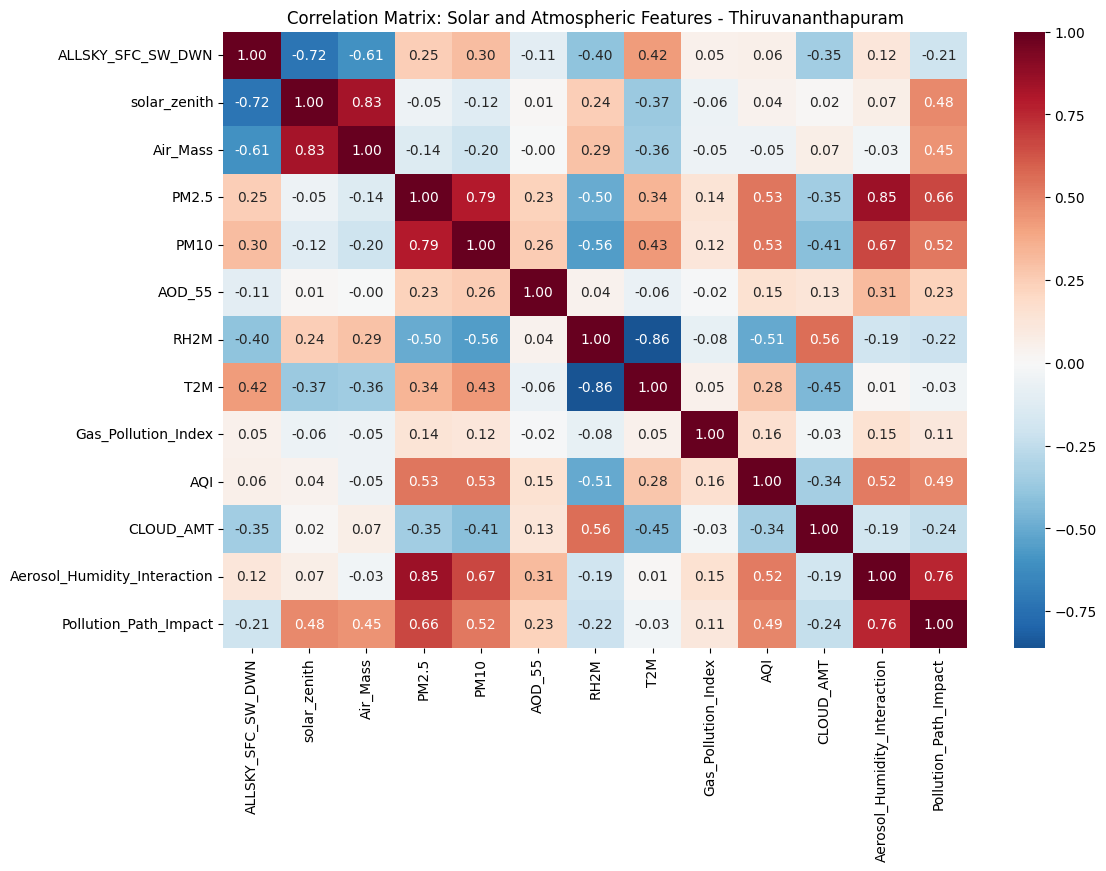

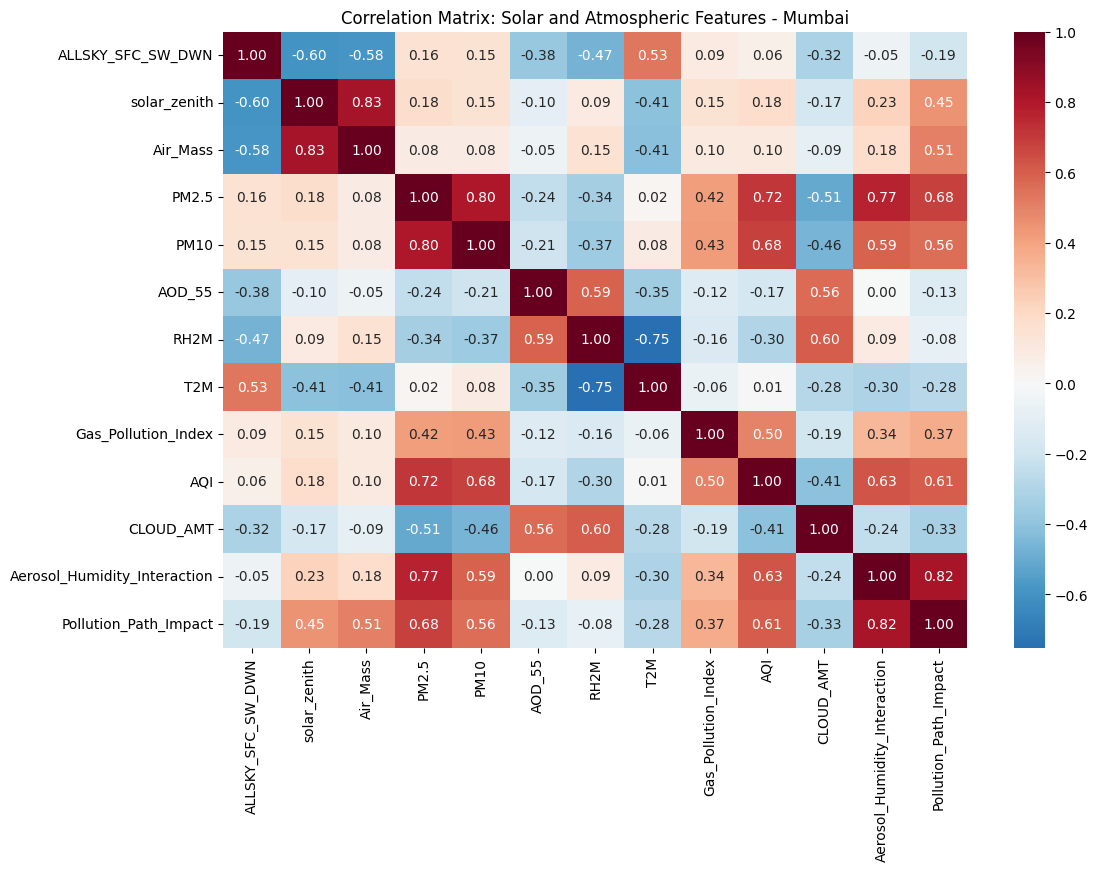

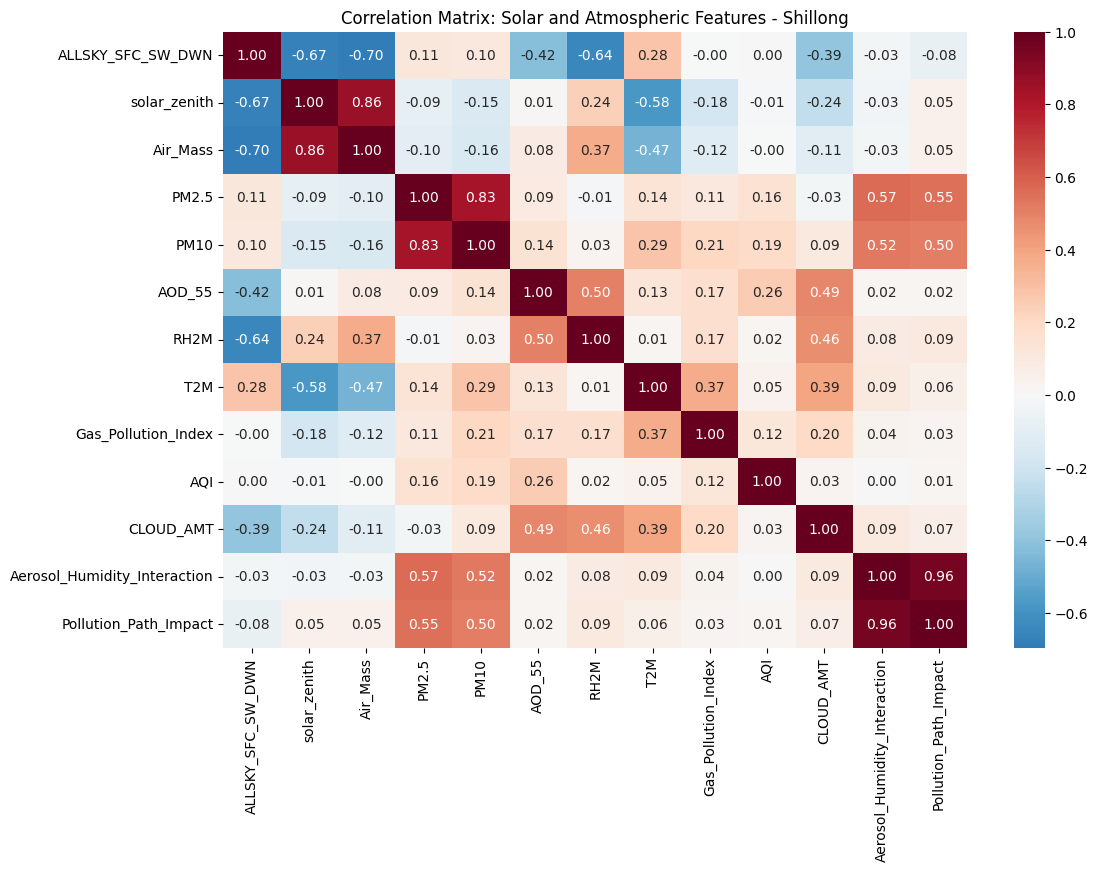

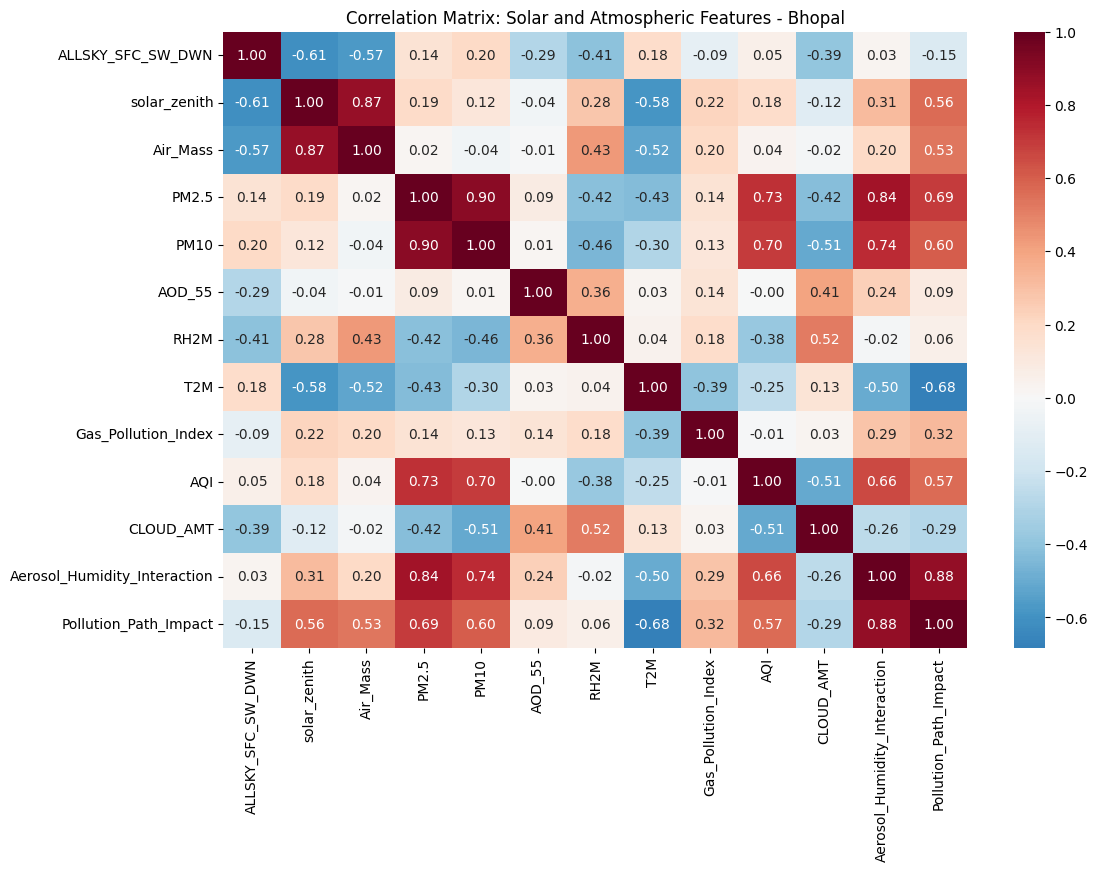

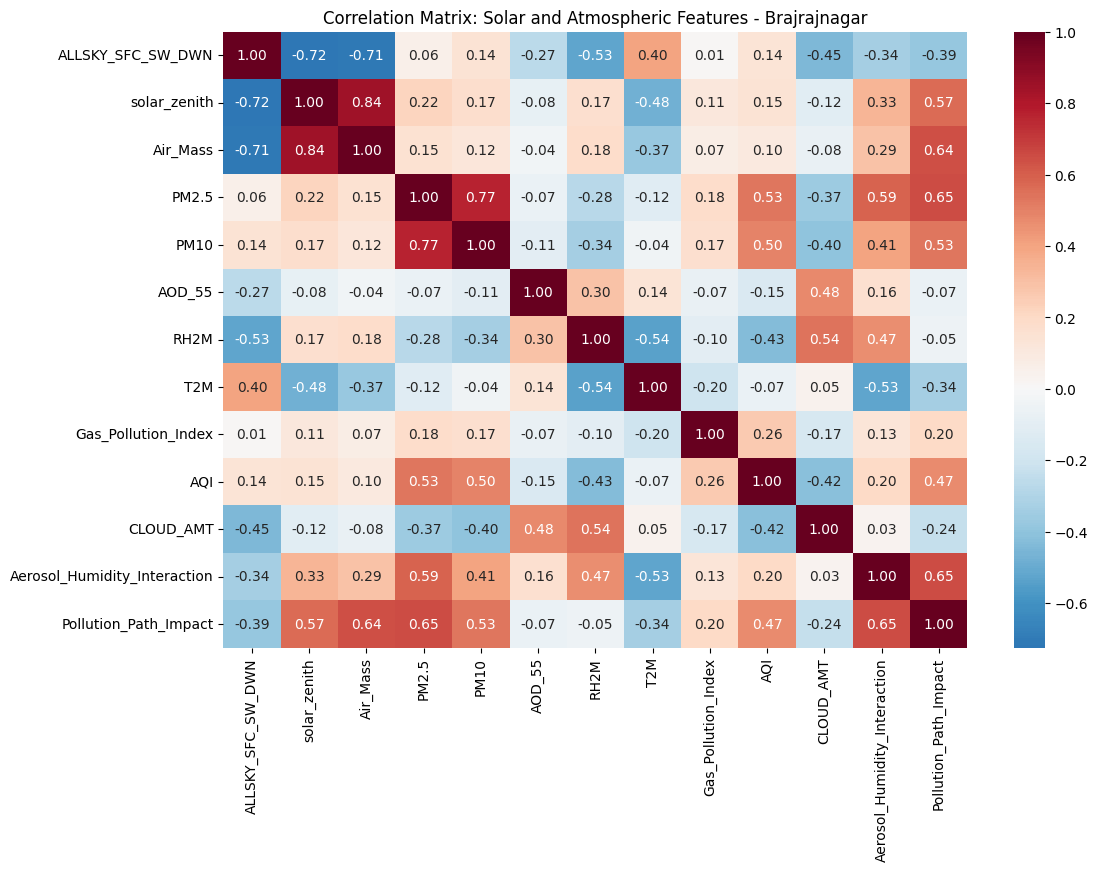

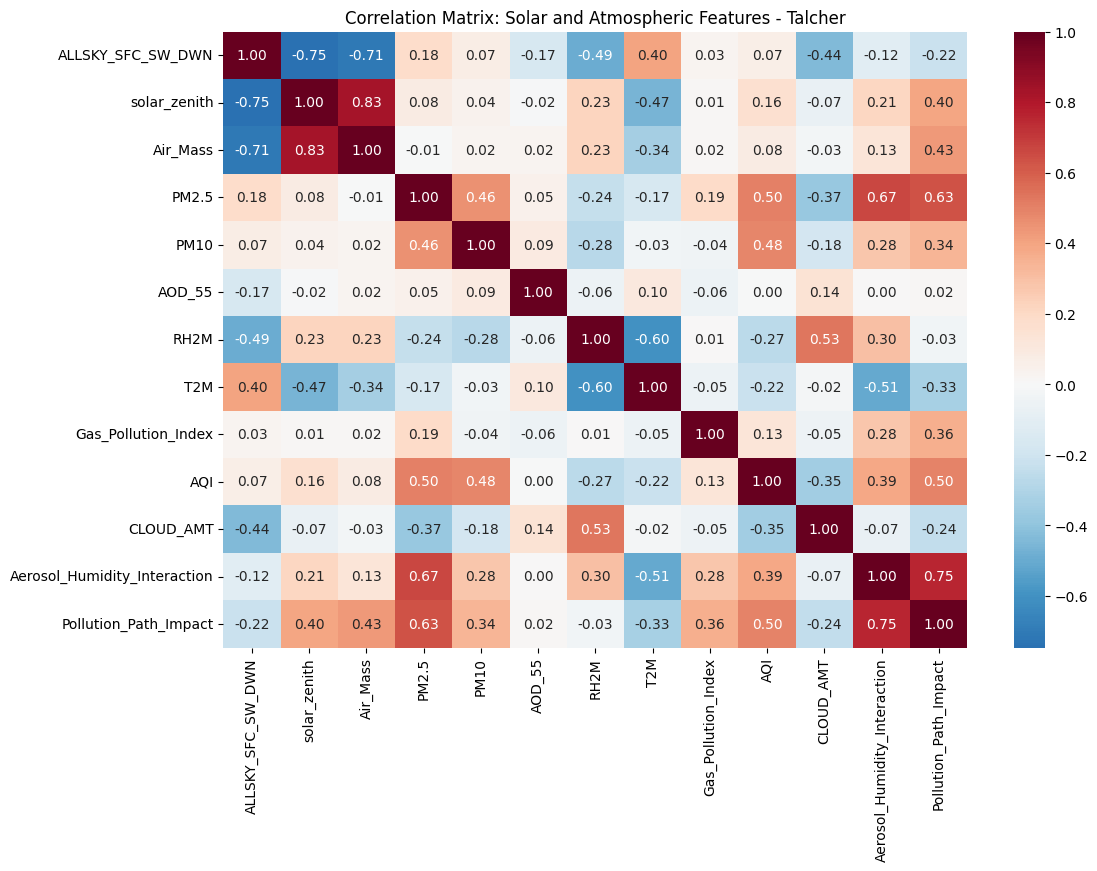

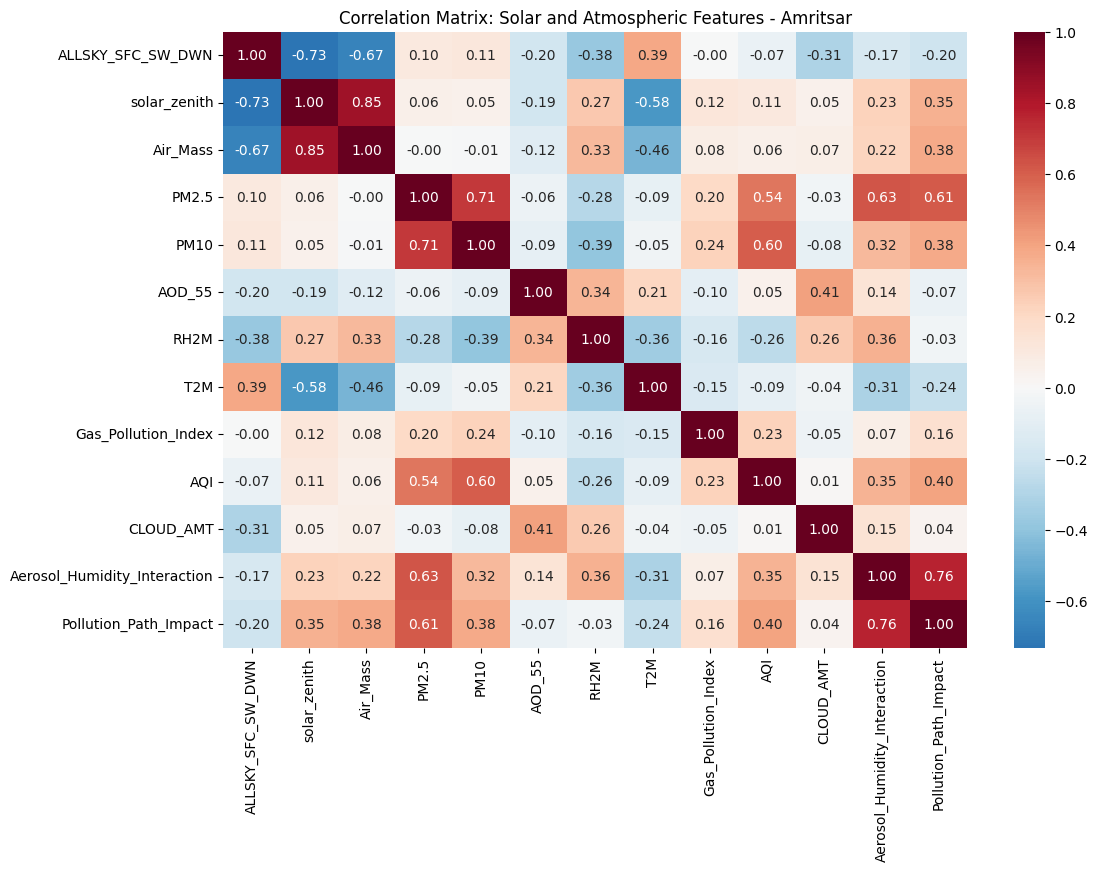

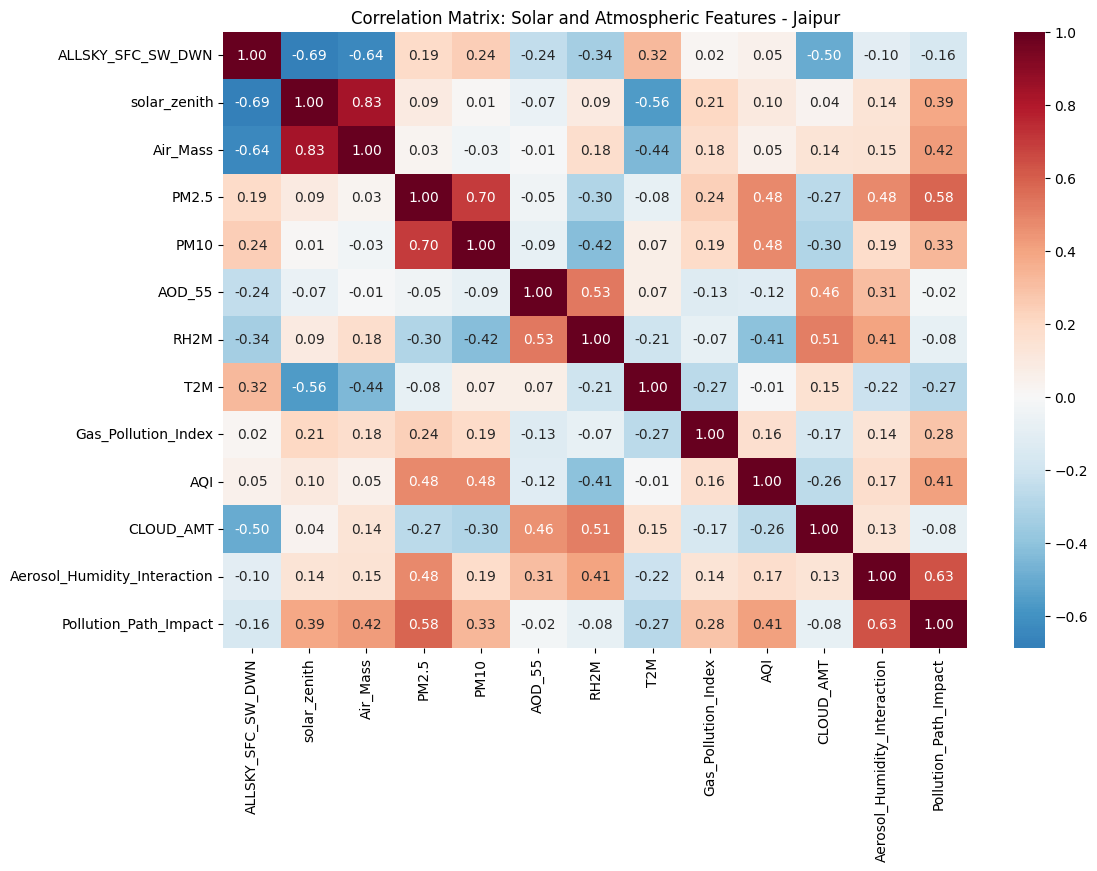

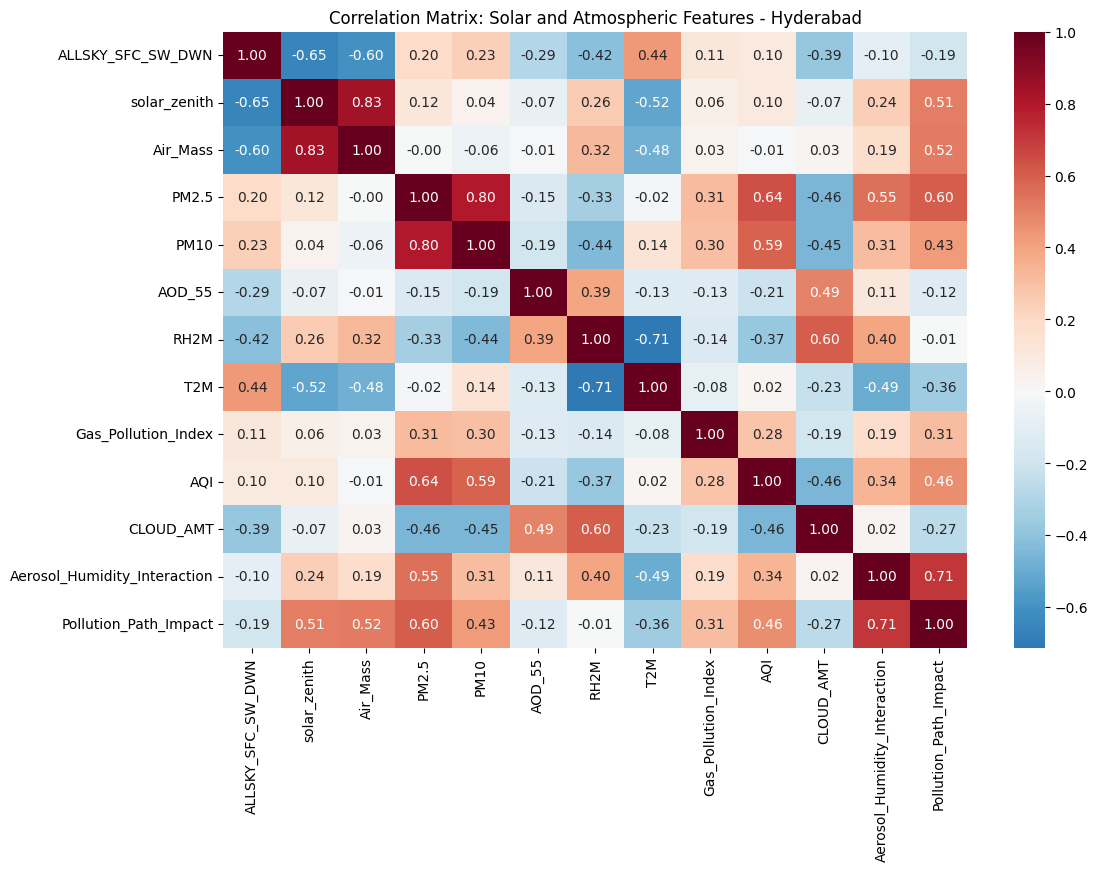

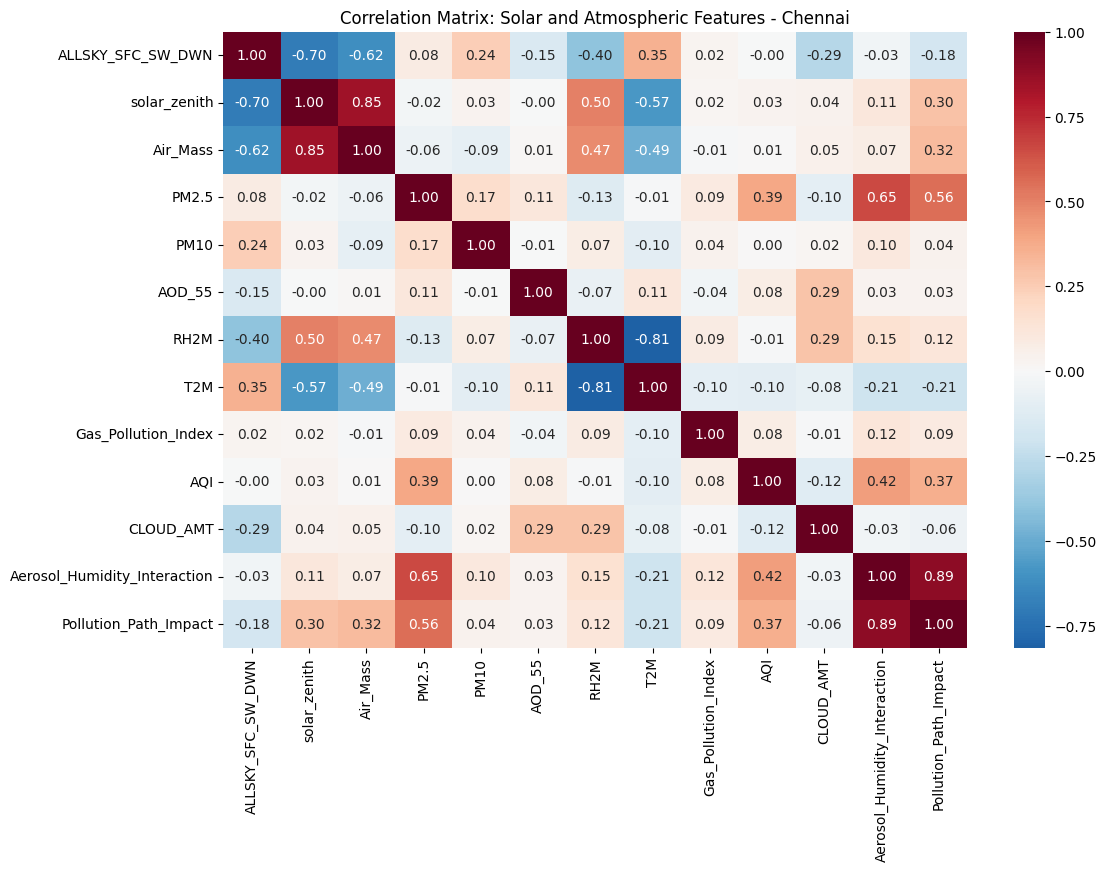

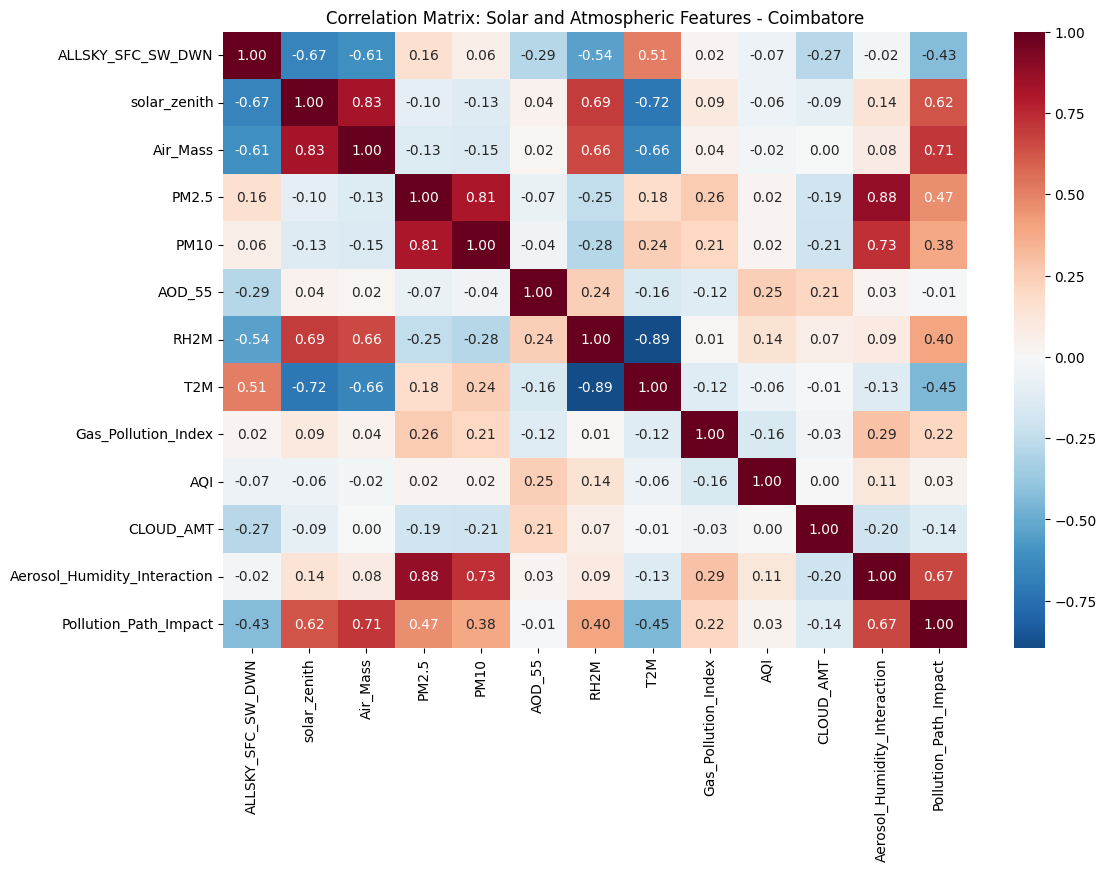

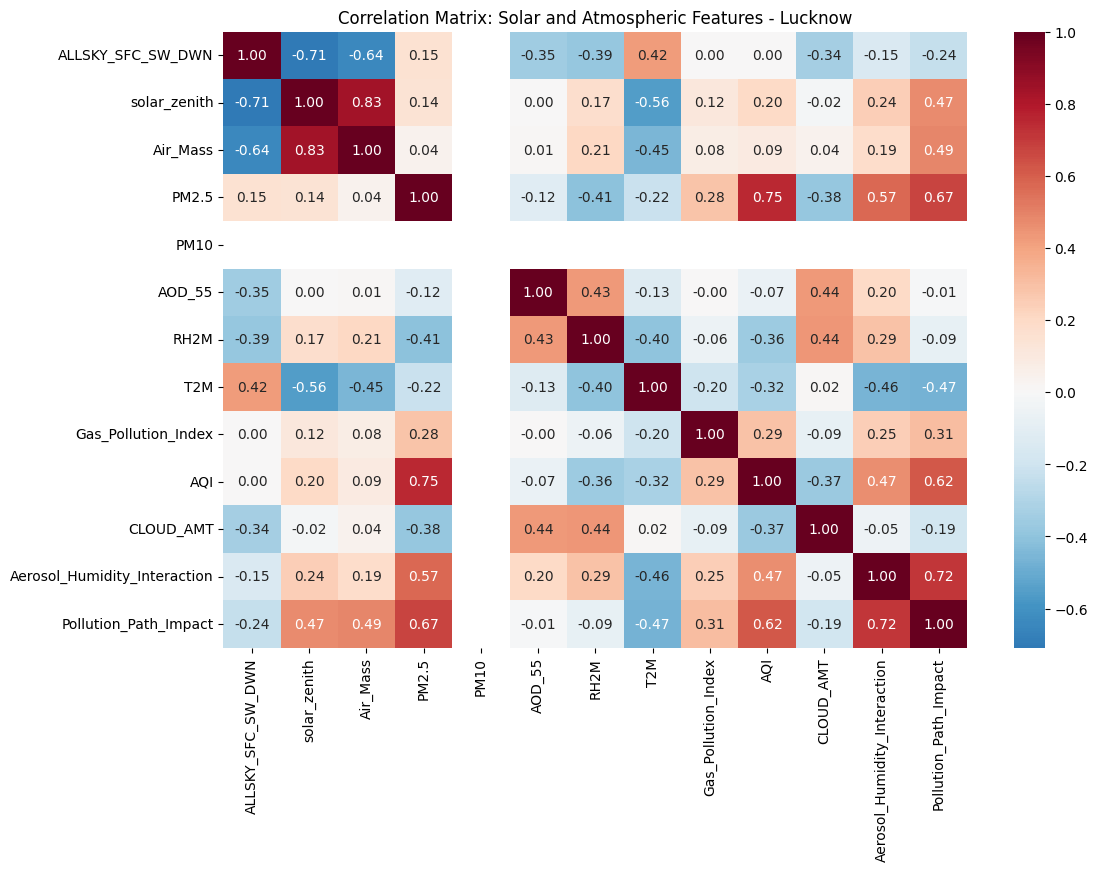

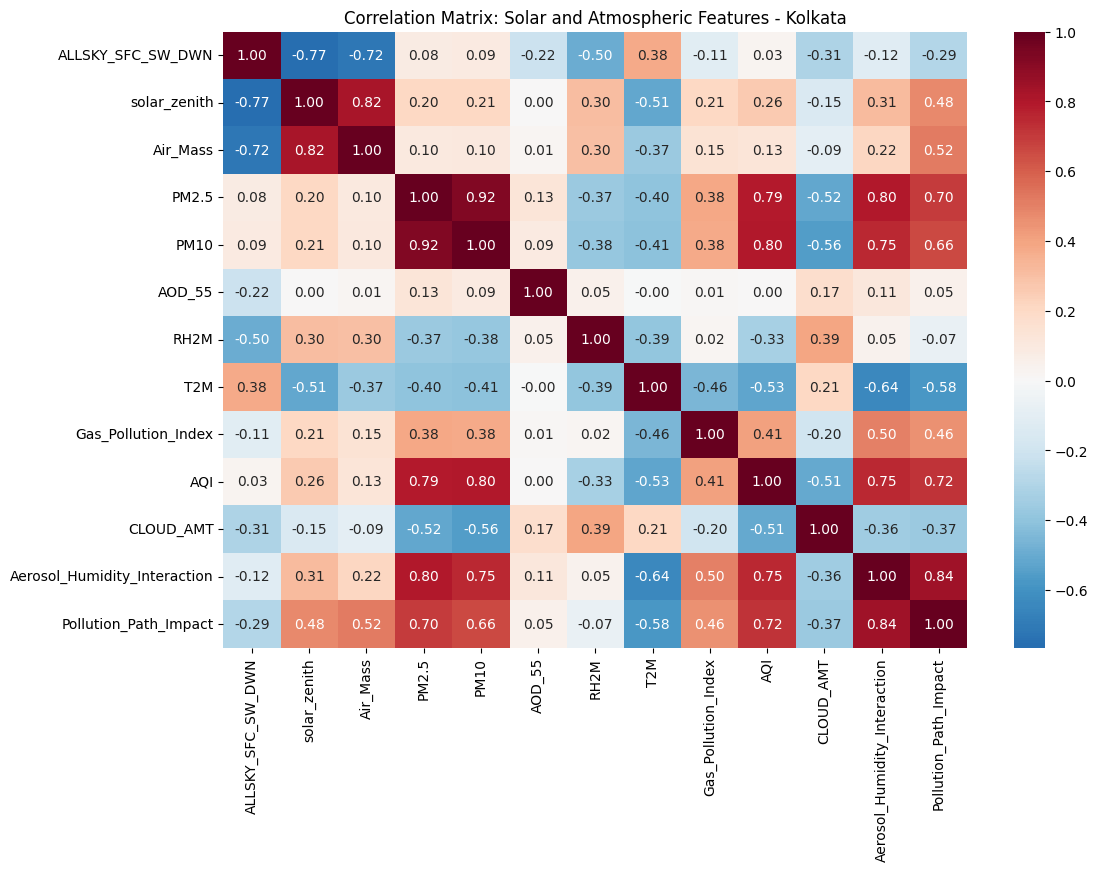

In [20]:
cities = df['City'].unique()

for city in cities:
    city_data = df[df['City'] == city]
    # 2. Calculate the correlation
    corr_matrix = city_data[corr_features].corr()

    # 3. Plot the Heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
    plt.title('Correlation Matrix: Solar and Atmospheric Features - ' + city)
    plt.show()

In [21]:
plt.figure(figsize=(12, 6))
# Plotting Time vs GHI, grouped by AQI Category
sns.lineplot(data=df, x='Hour', y='ALLSKY_SFC_SW_DWN', hue='AQI_Bucket', 
             palette='viridis', errorbar='sd')

plt.title('Diurnal Solar Radiation Curve across Pollution Levels (23 Cities)')
plt.xlabel('Hour of Day')
plt.ylabel('Global Horizontal Irradiance (W/m²)')
plt.grid(True, alpha=0.3)
plt.legend(title='AQI Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

ValueError: Could not interpret value `Hour` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [ ]:
city = 'Delhi'

city_data = df[df['City'] == city]
display(city_data.head(1000))

Loading ITables v2.7.0 from the internet... (need help?)


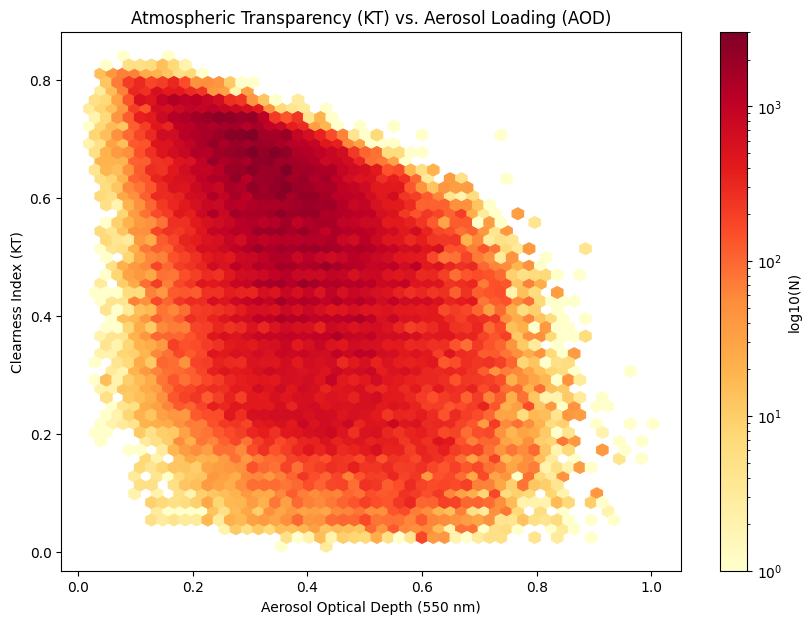

In [ ]:
plt.figure(figsize=(10, 7))
hb = plt.hexbin(df['AOD_55'], df['ALLSKY_KT'], gridsize=50, cmap='YlOrRd', bins='log')
cb = plt.colorbar(hb, label='log10(N)')
plt.title('Atmospheric Transparency (KT) vs. Aerosol Loading (AOD)')
plt.xlabel('Aerosol Optical Depth (550 nm)')
plt.ylabel('Clearness Index (KT)')
plt.show()

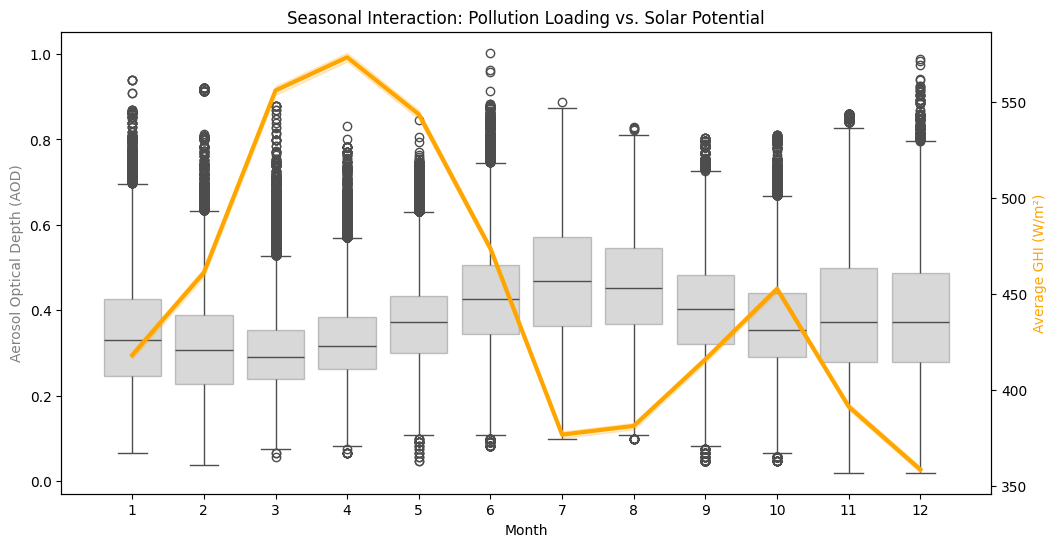

In [ ]:
# Create a Month column if not already present
df['Month'] = df['Date'].dt.month

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot AOD (Pollution)
sns.boxplot(data=df, x='Month', y='AOD_55', ax=ax1, color='gray', boxprops=dict(alpha=0.3))
ax1.set_ylabel('Aerosol Optical Depth (AOD)', color='gray')

# Create a second y-axis for GHI
ax2 = ax1.twinx()
sns.lineplot(data=df, x=df['Month']-1, y='ALLSKY_SFC_SW_DWN', ax=ax2, color='orange', linewidth=3)
ax2.set_ylabel('Average GHI (W/m²)', color='orange')

plt.title('Seasonal Interaction: Pollution Loading vs. Solar Potential')
plt.show()

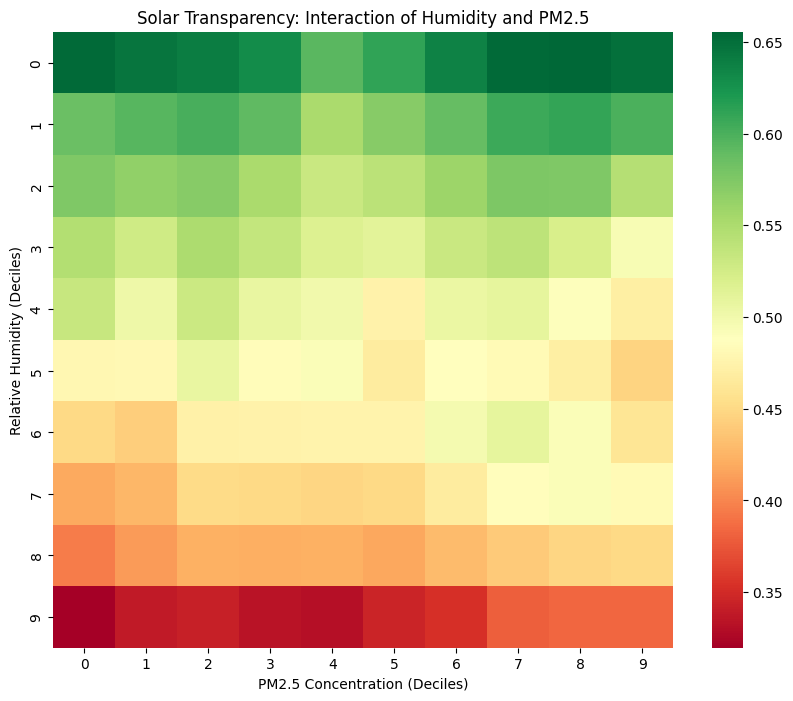

In [ ]:
# Discretize PM2.5 and Humidity for the heatmap
df['PM2.5_bins'] = pd.qcut(df['PM2.5'], 10, labels=False)
df['RH_bins'] = pd.qcut(df['RH2M'], 10, labels=False)

# Calculate the average Clearness Index for each bin combination
pivot_table = df.pivot_table(values='ALLSKY_KT', index='RH_bins', columns='PM2.5_bins', aggfunc='mean')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=False, cmap='RdYlGn')
plt.title('Solar Transparency: Interaction of Humidity and PM2.5')
plt.xlabel('PM2.5 Concentration (Deciles)')
plt.ylabel('Relative Humidity (Deciles)')
plt.show()

In [ ]:
# Calculate the "Solar Penalty" using Clear Sky baseline
df['Solar_Penalty'] = df['CLRSKY_SFC_SW_DWN'] - df['ALLSKY_SFC_SW_DWN']

summary = df.groupby('City').agg({
    'ALLSKY_SFC_SW_DWN': 'mean',
    'AOD_55': 'mean',
    'PM2.5': 'mean',
    'Solar_Penalty': 'mean'
}).sort_values(by='Solar_Penalty', ascending=False)

print("Top 10 Cities with Highest Average Solar Penalty (W/m²):")
print(summary.head(10))

Top 10 Cities with Highest Average Solar Penalty (W/m²):
                    ALLSKY_SFC_SW_DWN    AOD_55     PM2.5  Solar_Penalty
City                                                                    
Coimbatore                 394.678861  0.320836  1.449801     191.553332
Guwahati                   395.248116  0.354017  1.451033     153.506256
Shillong                   397.311164  0.258457  1.158960     135.391874
Mumbai                     412.539393  0.382748  1.399928     122.156141
Kolkata                    400.797563  0.435997  1.527339     112.805506
Bengaluru                  489.475548  0.319343  1.438041     110.497522
Thiruvananthapuram         484.726119  0.301326  1.387968     108.145631
Talcher                    446.206838  0.389595  1.548129     104.486238
Chennai                    474.723686  0.305365  1.519245     104.318790
Visakhapatnam              467.758774  0.355831  1.538022     103.256675


In [ ]:
df.to_csv('/content/drive/MyDrive/colab/mlpr/processed_data.csv', index=False)